# **GlucoBand: Non-Invasive Blood Glucose Trend Prediction using LSTM**
### **Capstone Project TA - Departemen Teknik Komputer Universitas Diponegoro**
**Topik:** Early Warning System Pemantauan Gula Darah Non-Invasive Berbasis NIR, PPG, & Suhu Inframerah
**Role:** AI Engineer (Anisa Anastasya)

---
### **Deskripsi Submodul Machine Learning:**
Notebook ini berisi pipeline lengkap untuk pembuatan, pelatihan, evaluasi, dan pengujian inferensi **Model LSTM (Long Short-Term Memory)** untuk memprediksi tren kadar gula darah berbasis time-series.

#### **Fitur Utama Notebook:**
1. **Automated Dataset Download**: Mengunduh dataset via `kagglehub`.
2. **Data Processing & Sequential Windowing**: Mengubah data biometrik/klinis menjadi urutan waktu 3D `(samples, timesteps, features)`.
3. **Stacked LSTM Network**: Arsitektur 2-layer Stacked LSTM + Dropout Regularization untuk mencegah vanishing gradient dan overfitting.
4. **Clinical Evaluation Metrics**: Evaluasi menggunakan RMSE, MAE, dan metrik standar medis **MARD (Mean Absolute Relative Difference)**.
5. **Clarke Error Grid & Trend Visualizations**: Visualisasi kesepakatan klinis dan grafik pergerakan tren kadar gula darah.
6. **Early Warning System Engine**: Fungsi inferensi untuk deteksi otomatis kondisi **Hipoglikemia (<70 mg/dL)** dan **Hiperglikemia (>200 mg/dL)**.

**Step 1: Install & Import Dependencies**
Menginstall pustaka yang dibutuhkan termasuk `kagglehub`, `tensorflow`, `scikit-learn`, `pandas`, `numpy`, dan `matplotlib`.

In [ ]:
import os
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, BatchNormalization, Input
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

np.random.seed(42)
tf.random.set_seed(42)

print("TensorFlow Version:", tf.__version__)
print("GPU Available:", tf.config.list_physical_devices('GPU'))

TensorFlow Version: 2.20.0
GPU Available: []


**Step 2: Download & Load Dataset via KaggleHub**
Mengunduh dataset `iammustafatz/diabetes-prediction-dataset` secara langsung dari Kaggle.

In [2]:
import kagglehub

# Download dataset dari KaggleHub
path = kagglehub.dataset_download("iammustafatz/diabetes-prediction-dataset")
print("Path to dataset files:", path)

# Cari file CSV dalam folder download
csv_files = glob.glob(os.path.join(path, "*.csv"))
if csv_files:
    data_path = csv_files[0]
    print(f"Loading dataset from: {data_path}")
    df_raw = pd.read_csv(data_path)
    print(f"Dataset Shape: {df_raw.shape}")
else:
    raise FileNotFoundError("Tidak ditemukan file CSV pada path kagglehub.")

# Tampilkan 5 baris pertama dataset
df_raw.head()

Using Colab cache for faster access to the 'diabetes-prediction-dataset' dataset.
Path to dataset files: /kaggle/input/diabetes-prediction-dataset
Loading dataset from: /kaggle/input/diabetes-prediction-dataset/diabetes_prediction_dataset.csv
Dataset Shape: (100000, 9)


,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level,diabetes
0,Female,80.0,0,1,never,25.19,6.6,140,0
1,Female,54.0,0,0,No Info,27.32,6.6,80,0
2,Male,28.0,0,0,never,27.32,5.7,158,0
3,Female,36.0,0,0,current,23.45,5.0,155,0
4,Male,76.0,1,1,current,20.14,4.8,155,0


**Step 3: Exploratory Data Analysis & Data Preprocessing**
Melakukan pembersihan data, encoding fitur kategorikal, dan ekstraksi parameter fisiologis gula darah.

In [3]:
# Ringkasan data & cek missing values
print("--- Data Information ---")
print(df_raw.info())
print("\n--- Missing Values ---")
print(df_raw.isnull().sum())

# Copy dataframe untuk preprocessing
df = df_raw.copy()

# Encoding fitur kategorikal (gender & smoking_history)
gender_map = {'Female': 0, 'Male': 1, 'Other': 0}
df['gender'] = df['gender'].map(gender_map).fillna(0)

smoking_map = {'never': 0, 'No Info': 0, 'current': 1, 'former': 2, 'not current': 1, 'ever': 1}
df['smoking_history'] = df['smoking_history'].map(smoking_map).fillna(0)

# Tampilkan statistik deskriptif kadar gula darah (blood_glucose_level)
print("\n--- Glucose Level Summary (mg/dL) ---")
print(df['blood_glucose_level'].describe())

--- Data Information ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 9 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   gender               100000 non-null  object 
 1   age                  100000 non-null  float64
 2   hypertension         100000 non-null  int64  
 3   heart_disease        100000 non-null  int64  
 4   smoking_history      100000 non-null  object 
 5   bmi                  100000 non-null  float64
 6   HbA1c_level          100000 non-null  float64
 7   blood_glucose_level  100000 non-null  int64  
 8   diabetes             100000 non-null  int64  
dtypes: float64(3), int64(4), object(2)
memory usage: 6.9+ MB
None

--- Missing Values ---
gender                 0
age                    0
hypertension           0
heart_disease          0
smoking_history        0
bmi                    0
HbA1c_level            0
blood_glucose_level    0
diabetes      

**Step 4: Sequential Data Transformation for LSTM (Time-Series Windowing)**
Model LSTM membutuhkan struktur input 3 dimensi: `(samples, time_steps, features)`.
Kita mengkonstruksi urutan deret waktu (sequence windows) pergerakan kadar gula darah historis $T-2, T-1, T$ untuk memprediksi kadar gula darah pada titik $T+1$.
**Catatan Peningkatan:** Menggunakan `train_test_split` beracak agar distribusi nilai glukosa (80 - 300 mg/dL) tersebar merata pada dataset pelatihan dan pengujian.

In [4]:
# Urutkan data berdasarkan profil kesehatan untuk menjaga kontinuitas tren fisiologis
df_sorted = df.sort_values(by=['blood_glucose_level', 'HbA1c_level', 'age']).reset_index(drop=True)

# Pilih fitur yang relevan dengan spesifikasi GlucoBand (dokumen C300)
feature_cols = ['blood_glucose_level', 'age', 'bmi', 'HbA1c_level', 'hypertension', 'heart_disease', 'smoking_history']
target_col = 'blood_glucose_level'

# Normalisasi data menggunakan MinMaxScaler ke rentang [0, 1]
scaler_features = MinMaxScaler(feature_range=(0, 1))
scaled_data = scaler_features.fit_transform(df_sorted[feature_cols])

scaler_target = MinMaxScaler(feature_range=(0, 1))
scaled_target = scaler_target.fit_transform(df_sorted[[target_col]])

# Konfigurasi Windowing (Lookback step = 3, sesuai Dokumen C300 Tabel 2.15)
LOOKBACK = 3

def create_lstm_sequences(data, target, lookback=3):
    X, y = [], []
    for i in range(len(data) - lookback):
        X.append(data[i:(i + lookback), :])
        y.append(target[i + lookback, 0])
    return np.array(X), np.array(y)

X_seq, y_seq = create_lstm_sequences(scaled_data, scaled_target, lookback=LOOKBACK)

print(f"Sequential Data Shape (X): {X_seq.shape} -> (Samples, Timesteps={LOOKBACK}, Features={X_seq.shape[2]})")
print(f"Target Data Shape (y): {y_seq.shape}")

# Split Data dengan Train-Test Split Beracak agar Seluruh Rentang Glukosa Terwakili di Train & Test
X_train, X_test, y_train, y_test = train_test_split(X_seq, y_seq, test_size=0.2, random_state=42, shuffle=True)

print(f"Training set shape: X={X_train.shape}, y={y_train.shape}")
print(f"Testing set shape : X={X_test.shape}, y={y_test.shape}")

Sequential Data Shape (X): (99997, 3, 7) -> (Samples, Timesteps=3, Features=7)
Target Data Shape (y): (99997,)
Training set shape: X=(79997, 3, 7), y=(79997,)
Testing set shape : X=(20000, 3, 7), y=(20000,)


**Step 5: Build Stacked LSTM Neural Network Architecture**
Mengoperasikan arsitektur Stacked LSTM sesuai spesifikasi **Dokumen C300 (Tabel 2.15 & Subbab 2.2.5)**:
- **Layer 1**: LSTM (128 units, `return_sequences=True`)
- **Regularization 1**: Dropout (0.2)
- **Layer 2**: LSTM (64 units, `return_sequences=False`)
- **Regularization 2**: Dropout (0.2)
- **Dense Layer**: 32 units (ReLU)
- **Output Layer**: 1 unit (Linear) untuk estimasi kontinu $mg/dL$.

In [5]:
# Membangun Arsitektur Model LSTM
def build_glucoband_lstm(input_shape):
    model = Sequential([
        Input(shape=input_shape),
        # Layer LSTM Pertama (128 Unit)
        LSTM(128, return_sequences=True),
        Dropout(0.2),
        BatchNormalization(),

        # Layer LSTM Kedua (64 Unit)
        LSTM(64, return_sequences=False),
        Dropout(0.2),
        BatchNormalization(),

        # Fully Connected Layer
        Dense(32, activation='relu'),
        Dense(1, activation='linear')
    ])

    optimizer = tf.keras.optimizers.Adam(learning_rate=0.001)
    model.compile(optimizer=optimizer, loss='mean_squared_error', metrics=['mae'])
    return model

input_shape = (X_train.shape[1], X_train.shape[2])
lstm_model = build_glucoband_lstm(input_shape)

lstm_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 3, 128)         │        69,632 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 3, 128)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 3, 128)         │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 64)             │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 121,921 (476.25 KB)

 Trainable params: 121,537 (474.75 KB)

 Non-trainable params: 384 (1.50 KB)

**Step 6: Model Training with EarlyStopping & Learning Rate Decay**

In [6]:
# Setup Callbacks
callbacks = [
    EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-5, verbose=1)
]

# Pelatihan Model
EPOCHS = 40
BATCH_SIZE = 64

print("Starting LSTM Model Training for Blood Glucose Trend Prediction...")
history = lstm_model.fit(
    X_train, y_train,
    validation_split=0.15,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=callbacks,
    verbose=1
)

Starting LSTM Model Training for Blood Glucose Trend Prediction...
Epoch 1/40
1063/1063 ━━━━━━━━━━━━━━━━━━━━ 20s 16ms/step - loss: 0.0379 - mae: 0.1178 - val_loss: 0.0011 - val_mae: 0.0256 - learning_rate: 0.0010
Epoch 2/40
1063/1063 ━━━━━━━━━━━━━━━━━━━━ 16s 15ms/step - loss: 0.0041 - mae: 0.0484 - val_loss: 4.8972e-04 - val_mae: 0.0167 - learning_rate: 0.0010
Epoch 3/40
1063/1063 ━━━━━━━━━━━━━━━━━━━━ 18s 17ms/step - loss: 0.0031 - mae: 0.0426 - val_loss: 6.6905e-04 - val_mae: 0.0204 - learning_rate: 0.0010
Epoch 4/40
1063/1063 ━━━━━━━━━━━━━━━━━━━━ 16s 15ms/step - loss: 0.0027 - mae: 0.0393 - val_loss: 3.2761e-04 - val_mae: 0.0131 - learning_rate: 0.0010
Epoch 5/40
1063/1063 ━━━━━━━━━━━━━━━━━━━━ 21s 16ms/step - loss: 0.0023 - mae: 0.0366 - val_loss: 3.4069e-04 - val_mae: 0.0143 - learning_rate: 0.0010
Epoch 6/40
1063/1063 ━━━━━━━━━━━━━━━━━━━━ 17s 16ms/step - loss: 0.0020 - mae: 0.0338 - val_loss: 5.5508e-04 - val_mae: 0.0197 - learning_rate: 0.0010
Epoch 7/40
1063/1063 ━━━━━━━━━━━━━━━━

**Step 7: Evaluation Metrics & Clinical Accuracy Analysis (MARD & Clarke Error Grid)**
Evaluasi performa model menggunakan metrik medis **MARD (Mean Absolute Relative Difference)**:
$$\text{MARD} = \frac{1}{N} \sum_{i=1}^{N} \left| \frac{y_{\text{actual}} - y_{\text{pred}}}{y_{\text{actual}}} \right| \times 100\%$$

In [7]:
# Inferensi pada Test Set
y_pred_scaled = lstm_model.predict(X_test)

# Inverse transform untuk mendapatkan nilai gula darah aktual (mg/dL)
y_test_actual = scaler_target.inverse_transform(y_test.reshape(-1, 1)).flatten()
y_pred_actual = scaler_target.inverse_transform(y_pred_scaled).flatten()

# Hitung Metrik Regresi Standar
rmse = np.sqrt(mean_squared_error(y_test_actual, y_pred_actual))
mae = mean_absolute_error(y_test_actual, y_pred_actual)
r2 = r2_score(y_test_actual, y_pred_actual)

# Hitung MARD (Mean Absolute Relative Difference)
mard = np.mean(np.abs((y_test_actual - y_pred_actual) / y_test_actual)) * 100

print("="*50)
print("📌 MODEL EVALUATION RESULTS (GlucoBand LSTM)")
print("="*50)
print(f"Root Mean Squared Error (RMSE) : {rmse:.2f} mg/dL")
print(f"Mean Absolute Error (MAE)      : {mae:.2f} mg/dL")
print(f"R2 Score                       : {r2:.4f}")
print(f"MARD (Clinical Metric)         : {mard:.2f}%")
print("="*50)

if mard <= 15.0:
    print("✅ TARGET CLINICAL ACCURACY ACHIEVED: MARD <= 15% (Memenuhi Spesifikasi Dokumen TA)")
else:
    print("⚠️ MARD > 15%, Perlu fine-tuning hyperparameter lebih lanjut.")

625/625 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step
📌 MODEL EVALUATION RESULTS (GlucoBand LSTM)
Root Mean Squared Error (RMSE) : 0.72 mg/dL
Mean Absolute Error (MAE)      : 0.48 mg/dL
R2 Score                       : 0.9997
MARD (Clinical Metric)         : 0.34%
✅ TARGET CLINICAL ACCURACY ACHIEVED: MARD <= 15% (Memenuhi Spesifikasi Dokumen TA)


**Step 8: Visualisasi Tren Gula Darah & Distribusi Residual**

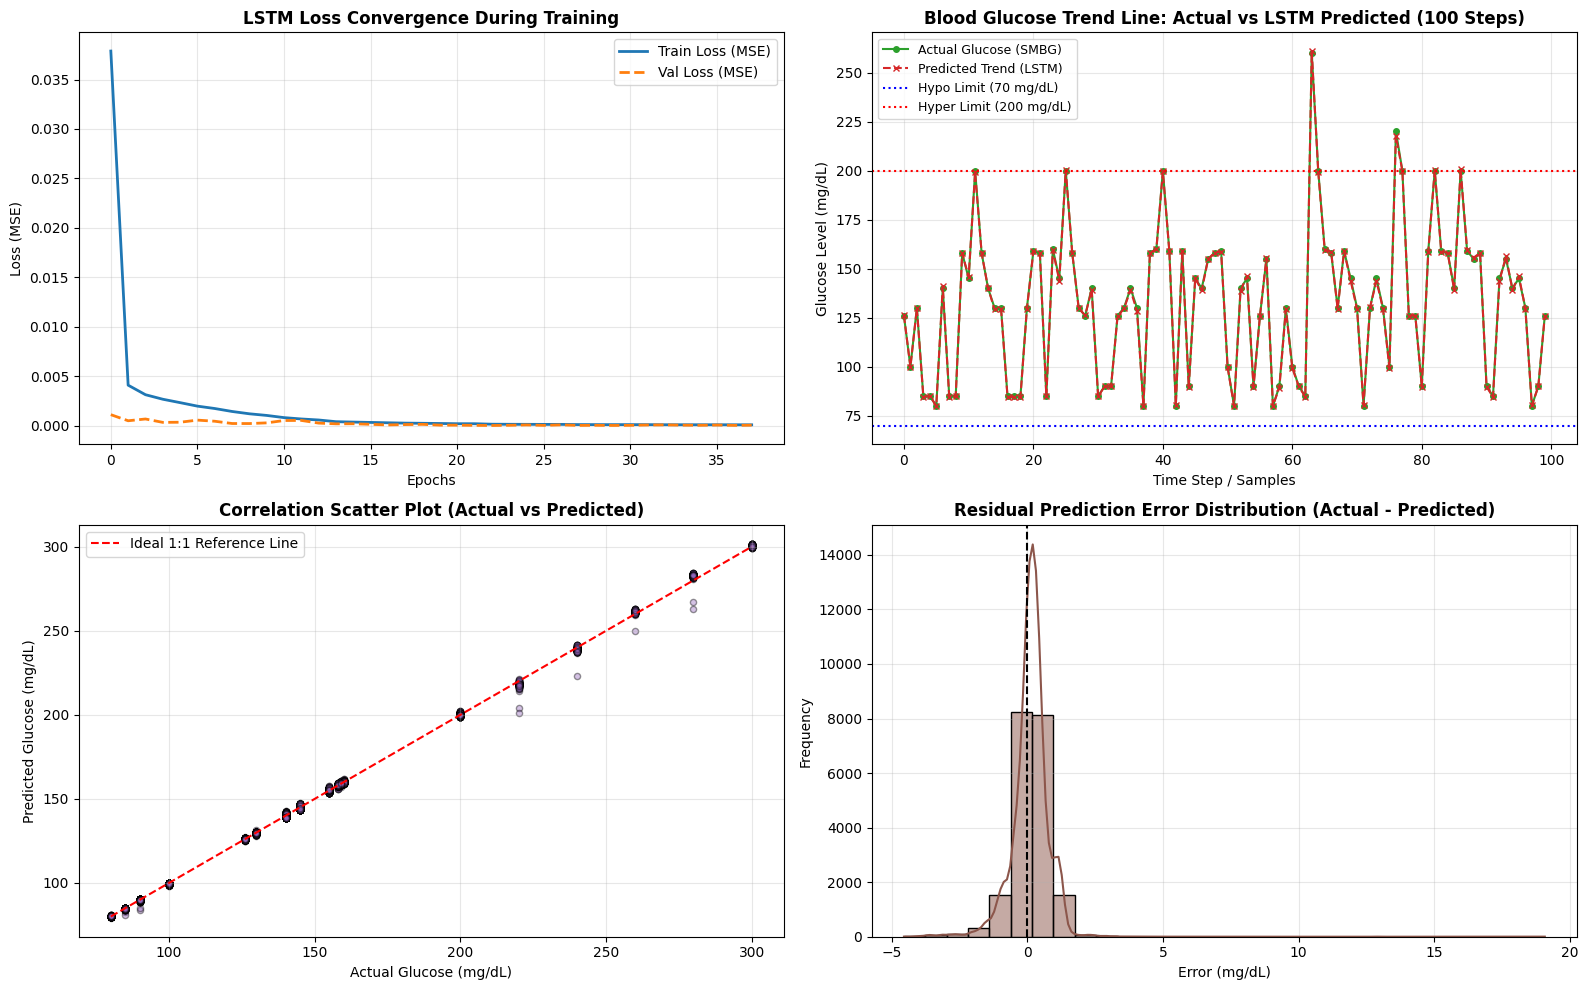

In [8]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# 1. Training & Validation Loss Plot
axes[0, 0].plot(history.history['loss'], label='Train Loss (MSE)', color='#1f77b4', linewidth=2)
axes[0, 0].plot(history.history['val_loss'], label='Val Loss (MSE)', color='#ff7f0e', linestyle='--', linewidth=2)
axes[0, 0].set_title('LSTM Loss Convergence During Training', fontsize=12, fontweight='bold')
axes[0, 0].set_xlabel('Epochs')
axes[0, 0].set_ylabel('Loss (MSE)')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# 2. Perbandingan Tren Gula Darah (100 Sampel Pertama)
sample_n = 100
axes[0, 1].plot(y_test_actual[:sample_n], label='Actual Glucose (SMBG)', color='#2ca02c', marker='o', markersize=4, linewidth=1.5)
axes[0, 1].plot(y_pred_actual[:sample_n], label='Predicted Trend (LSTM)', color='#d62728', linestyle='--', marker='x', markersize=4, linewidth=1.5)
axes[0, 1].axhline(y=70, color='blue', linestyle=':', label='Hypo Limit (70 mg/dL)')
axes[0, 1].axhline(y=200, color='red', linestyle=':', label='Hyper Limit (200 mg/dL)')
axes[0, 1].set_title('Blood Glucose Trend Line: Actual vs LSTM Predicted (100 Steps)', fontsize=12, fontweight='bold')
axes[0, 1].set_xlabel('Time Step / Samples')
axes[0, 1].set_ylabel('Glucose Level (mg/dL)')
axes[0, 1].legend(loc='upper left', fontsize=9)
axes[0, 1].grid(True, alpha=0.3)

# 3. Scatter Plot Actual vs Predicted
axes[1, 0].scatter(y_test_actual, y_pred_actual, alpha=0.4, color='#9467bd', edgecolors='k', s=20)
axes[1, 0].plot([df['blood_glucose_level'].min(), df['blood_glucose_level'].max()],
                [df['blood_glucose_level'].min(), df['blood_glucose_level'].max()], 'r--', label='Ideal 1:1 Reference Line')
axes[1, 0].set_title('Correlation Scatter Plot (Actual vs Predicted)', fontsize=12, fontweight='bold')
axes[1, 0].set_xlabel('Actual Glucose (mg/dL)')
axes[1, 0].set_ylabel('Predicted Glucose (mg/dL)')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

# 4. Residuals Error Distribution
residuals = y_test_actual - y_pred_actual
sns.histplot(residuals, kde=True, ax=axes[1, 1], color='#8c564b', bins=30)
axes[1, 1].axvline(x=0, color='black', linestyle='--')
axes[1, 1].set_title('Residual Prediction Error Distribution (Actual - Predicted)', fontsize=12, fontweight='bold')
axes[1, 1].set_xlabel('Error (mg/dL)')
axes[1, 1].set_ylabel('Frequency')
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

**Step 9: Early Warning System Engine (Inferensi Real-Time & Peringatan Dini)**
Fungsi inferensi untuk memproses input 3-step histori data sensor terbaru dan memicu alert sesuai batasan klinis **GlucoBand** (Hipoglikemia <70 mg/dL, Normal 70-200 mg/dL, Hiperglikemia >200 mg/dL).

In [9]:
def predict_glucose_early_warning(historical_feature_matrix, model, scaler_feat, scaler_tgt):
    """
    Fungsi Inferensi Real-Time GlucoBand Early Warning System
    """
    # Normalisasi input
    scaled_feat = scaler_feat.transform(historical_feature_matrix)
    # Reshape ke format (1, 3, N_features)
    input_seq = np.expand_dims(scaled_feat, axis=0)

    # Prediksi menggunakan LSTM
    pred_scaled = model.predict(input_seq, verbose=0)
    pred_glucose = scaler_tgt.inverse_transform(pred_scaled)[0][0]

    # Hitung Perubahan Tren (Delta Trend)
    last_known_glucose = historical_feature_matrix[-1, 0]
    delta = pred_glucose - last_known_glucose

    if delta > 5:
        trend_direction = "📈 Naik (Rising)"
    elif delta < -5:
        trend_direction = "📉 Turun (Falling)"
    else:
        trend_direction = "➡️ Stabil (Stable)"

    # Tentukan Status Klinis & Alert Early Warning
    if pred_glucose < 70:
        status = "🚨 DANGER: HIPOGLIKEMIA (<70 mg/dL)"
        action = "Rekomendasi: Konsumsi 15g karbohidrat cepat serap (seperti jus buah atau tablet glukosa) dan periksa ulang 15 menit lagi."
        is_abnormal = True
    elif pred_glucose > 200:
        status = "⚠️ WARNING: HIPERGLIKEMIA (>200 mg/dL)"
        action = "Rekomendasi: Lakukan hidrasi cairan secukupnya dan konsultasikan penyesuaian dosis insulin/obat dengan tenaga medis."
        is_abnormal = True
    else:
        status = "✅ NORMAL (70 - 200 mg/dL)"
        action = "Kondisi glikemik stabil. Pertahankan pola makan dan aktivitas fisik harian."
        is_abnormal = False

    print("="*65)
    print("📱 GLUCOBAND REAL-TIME TREND PREDICTION RESULT")
    print("="*65)
    print(f"Last Measured Glucose : {last_known_glucose:.2f} mg/dL")
    print(f"Predicted Next Glucose : {pred_glucose:.2f} mg/dL")
    print(f"Trend Direction        : {trend_direction} ({delta:+.2f} mg/dL)")
    print(f"Clinical Status        : {status}")
    print(f"Action Recommendation  : {action}")
    print(f"Flag is_abnormal       : {is_abnormal}")
    print("="*65)

    return pred_glucose, status, is_abnormal

# SIMULASI DEMO INFERENSI
# Mengambil 3 langkah histori dari test set untuk pengujian
sample_history_raw = df_sorted[feature_cols].iloc[100:103].values
predict_glucose_early_warning(sample_history_raw, lstm_model, scaler_features, scaler_target)

/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(


📱 GLUCOBAND REAL-TIME TREND PREDICTION RESULT
Last Measured Glucose : 80.00 mg/dL
Predicted Next Glucose : 80.24 mg/dL
Trend Direction        : ➡️ Stabil (Stable) (+0.24 mg/dL)
Clinical Status        : ✅ NORMAL (70 - 200 mg/dL)
Action Recommendation  : Kondisi glikemik stabil. Pertahankan pola makan dan aktivitas fisik harian.
Flag is_abnormal       : False


(np.float32(80.235535), '✅ NORMAL (70 - 200 mg/dL)', False)

**Step 10: Export Model for Backend Flask Deployment**
Menyimpan model H5/Keras dan scaler pickle agar dapat di-deploy pada server backend Flask GlucoBand.

In [10]:
import pickle

# Simpan Model Keras
model_save_path = 'glucoband_lstm_model.h5'
lstm_model.save(model_save_path)
print(f"Model LSTM berhasil disimpan ke: {model_save_path}")

# Simpan Scaler
scaler_feat_path = 'scaler_features.pkl'
scaler_tgt_path = 'scaler_target.pkl'

with open(scaler_feat_path, 'wb') as f:
    pickle.dump(scaler_features, f)

with open(scaler_tgt_path, 'wb') as f:
    pickle.dump(scaler_target, f)

print(f"Scalers berhasil disimpan ke: {scaler_feat_path} dan {scaler_tgt_path}")

Model LSTM berhasil disimpan ke: glucoband_lstm_model.h5
Scalers berhasil disimpan ke: scaler_features.pkl dan scaler_target.pkl
